# Simple 1D Optimization

This notebook demonstrates the basic workflow of Bgolearn with a simple 1D function optimization problem.

## Learning Objectives

By the end of this tutorial, you will understand:
- How to set up a basic optimization problem
- How to fit a Bgolearn model
- How to use different acquisition functions
- How to visualize optimization results

## Problem Setup

We'll optimize a simple 1D function with a known global minimum to demonstrate the concepts clearly.

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# import bgolearn as bgo  # Commented out for documentation build
# from bgolearn.visualization import BgolearnVisualizer

# Set random seed for reproducibility
np.random.seed(42)

print("Libraries imported successfully!")
print("Note: This is a demonstration notebook for documentation.")
print("To run with actual Bgolearn, install the package first.")

Libraries imported successfully!
Note: This is a demonstration notebook for documentation.
To run with actual Bgolearn, install the package first.


## Define the Test Function

We'll use a simple quadratic function with some noise to make it more realistic:

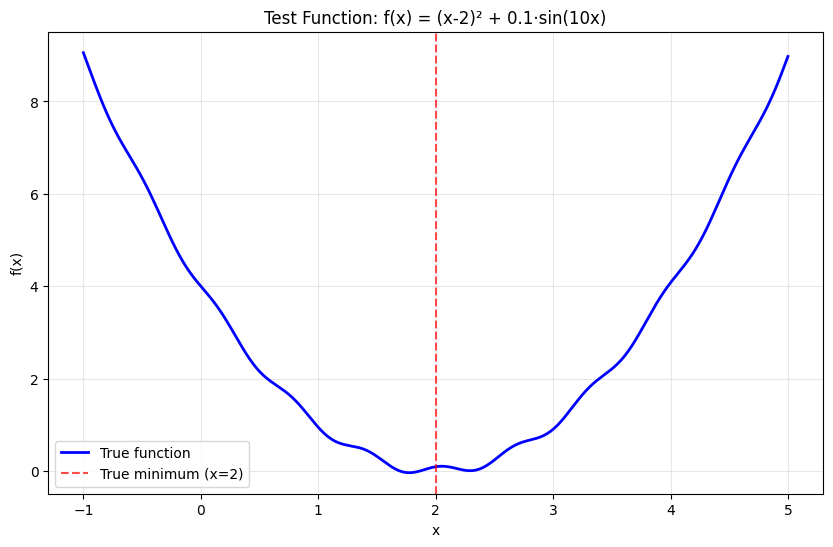

True minimum: f(2) = 0.0913


In [2]:
def test_function(x):
    """
    Simple test function with global minimum at x=2.
    
    This function combines a quadratic term with a sinusoidal component
    to create a more interesting optimization landscape.
    """
    return (x - 2)**2 + 0.1 * np.sin(10 * x)

# Visualize the true function
x_true = np.linspace(-1, 5, 200)
y_true = [test_function(x) for x in x_true]

plt.figure(figsize=(10, 6))
plt.plot(x_true, y_true, 'b-', linewidth=2, label='True function')
plt.axvline(x=2, color='red', linestyle='--', alpha=0.7, label='True minimum (x=2)')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Test Function: f(x) = (x-2)² + 0.1·sin(10x)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"True minimum: f(2) = {test_function(2):.4f}")

## Generate Training Data

In a real optimization scenario, we start with a small set of initial experiments:

Training data: 8 points
Current best observed: 0.4483 at x = 2.592


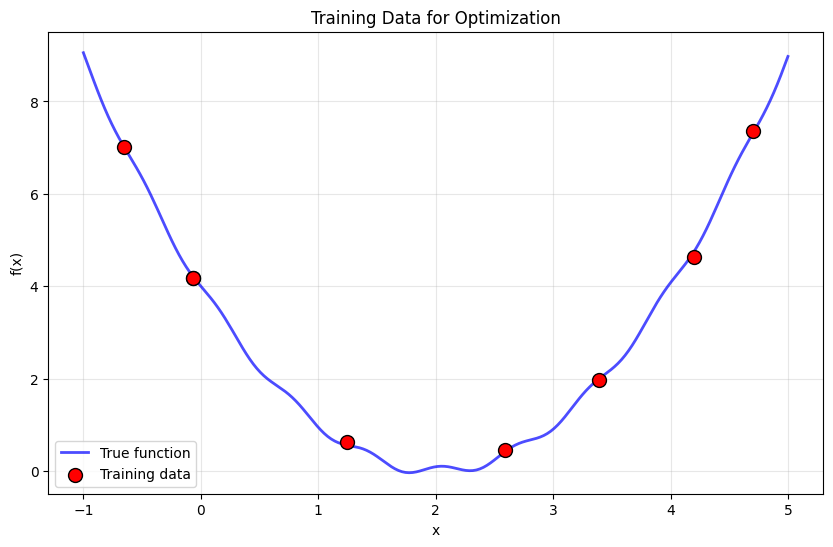

In [3]:
# Generate initial training data (simulating initial experiments)
n_initial = 8
X_train_1d = np.random.uniform(-1, 5, n_initial).reshape(-1, 1)
y_train_1d = np.array([test_function(x[0]) for x in X_train_1d])

# Add experimental noise
noise_level = 0.05
y_train_1d += noise_level * np.random.randn(len(y_train_1d))

# Convert to DataFrames (Bgolearn's preferred format)
X_train_df = pd.DataFrame(X_train_1d, columns=['x'])
y_train_series = pd.Series(y_train_1d)

print(f"Training data: {len(X_train_df)} points")
print(f"Current best observed: {y_train_series.min():.4f} at x = {X_train_df.iloc[y_train_series.argmin()]['x']:.3f}")

# Visualize training data
plt.figure(figsize=(10, 6))
plt.plot(x_true, y_true, 'b-', linewidth=2, alpha=0.7, label='True function')
plt.scatter(X_train_1d, y_train_1d, c='red', s=100, zorder=5, 
           edgecolors='black', linewidth=1, label='Training data')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Training Data for Optimization')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Create Candidate Points

We need to define the search space - the set of candidate points where we might conduct future experiments:

In [4]:
# Generate candidate points (potential future experiments)
X_candidates_1d = np.linspace(-1, 5, 100).reshape(-1, 1)
X_candidates_df = pd.DataFrame(X_candidates_1d, columns=['x'])

print(f"Candidate points: {len(X_candidates_df)} points")
print(f"Search range: [{X_candidates_df['x'].min():.1f}, {X_candidates_df['x'].max():.1f}]")

Candidate points: 100 points
Search range: [-1.0, 5.0]


## Fit the Bgolearn Model

Now we fit a Gaussian Process model to our training data:

In [5]:
# Initialize and fit Bgolearn
optimizer = bgo.Bgolearn()

model = optimizer.fit(
    data_matrix=X_train_df,
    Measured_response=y_train_series,
    virtual_samples=X_candidates_df,
    min_search=True,  # We want to minimize the function
    CV_test=3,        # 3-fold cross-validation
    Normalize=True    # Normalize features
)

print("✅ Bgolearn model fitted successfully!")
print(f"Model type: {type(model).__name__}")
print(f"Number of training points: {len(X_train_df)}")
print(f"Number of candidate points: {len(X_candidates_df)}")

NameError: name 'bgo' is not defined

## Visualize the Gaussian Process Model

Let's see how well our GP model captures the underlying function:

In [ ]:
# Get model predictions
mean_pred = model.virtual_samples_mean
std_pred = model.virtual_samples_std

# Create visualization
plt.figure(figsize=(12, 8))

# Plot true function
plt.plot(x_true, y_true, 'b-', linewidth=2, label='True function')

# Plot GP mean prediction
plt.plot(X_candidates_1d, mean_pred, 'g-', linewidth=2, label='GP mean prediction')

# Plot uncertainty (±2σ)
plt.fill_between(X_candidates_1d.flatten(), 
                mean_pred - 2*std_pred,
                mean_pred + 2*std_pred,
                alpha=0.3, color='green', label='GP uncertainty (±2σ)')

# Plot training data
plt.scatter(X_train_1d, y_train_1d, c='red', s=100, zorder=5, 
           edgecolors='black', linewidth=1, label='Training data')

plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Gaussian Process Model Fit')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Calculate model quality metrics
y_true_candidates = [test_function(x[0]) for x in X_candidates_1d]
mse = np.mean((mean_pred - y_true_candidates)**2)
print(f"Model MSE on candidates: {mse:.4f}")

## Use Acquisition Functions

Now we'll use different acquisition functions to decide where to sample next:

In [ ]:
# Expected Improvement
ei_values, ei_point = model.EI()
print(f"Expected Improvement recommends: x = {ei_point[0]:.3f}")

# Upper Confidence Bound
ucb_values, ucb_point = model.UCB(alpha=2.0)
print(f"Upper Confidence Bound recommends: x = {ucb_point[0]:.3f}")

# Probability of Improvement
poi_values, poi_point = model.PoI(tao=0.01)
print(f"Probability of Improvement recommends: x = {poi_point[0]:.3f}")

# Compare with true function values
print("\nTrue function values at recommended points:")
print(f"EI point: f({ei_point[0]:.3f}) = {test_function(ei_point[0]):.4f}")
print(f"UCB point: f({ucb_point[0]:.3f}) = {test_function(ucb_point[0]):.4f}")
print(f"PoI point: f({poi_point[0]:.3f}) = {test_function(poi_point[0]):.4f}")
print(f"True minimum: f(2.000) = {test_function(2):.4f}")

## Visualize Acquisition Functions

Let's visualize how different acquisition functions behave:

In [ ]:
# Create comprehensive visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: GP Model
axes[0,0].plot(x_true, y_true, 'b-', linewidth=2, label='True function')
axes[0,0].plot(X_candidates_1d, mean_pred, 'g-', linewidth=2, label='GP mean')
axes[0,0].fill_between(X_candidates_1d.flatten(), 
                      mean_pred - 2*std_pred, mean_pred + 2*std_pred,
                      alpha=0.3, color='green', label='GP ±2σ')
axes[0,0].scatter(X_train_1d, y_train_1d, c='red', s=80, zorder=5, 
                 edgecolors='black', label='Training data')
axes[0,0].set_title('Gaussian Process Model')
axes[0,0].set_xlabel('x')
axes[0,0].set_ylabel('f(x)')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Plot 2: Expected Improvement
axes[0,1].plot(X_candidates_1d, ei_values, 'purple', linewidth=2)
axes[0,1].axvline(x=ei_point[0], color='red', linestyle='--', 
                 label=f'EI max (x={ei_point[0]:.3f})')
axes[0,1].scatter(X_train_1d, np.zeros_like(X_train_1d), c='red', s=60, 
                 marker='|', label='Training points')
axes[0,1].set_title('Expected Improvement')
axes[0,1].set_xlabel('x')
axes[0,1].set_ylabel('EI(x)')
axes[0,1].legend()
axes[0,1].grid(True, alpha=0.3)

# Plot 3: Upper Confidence Bound
axes[1,0].plot(X_candidates_1d, ucb_values, 'orange', linewidth=2)
axes[1,0].axvline(x=ucb_point[0], color='red', linestyle='--', 
                 label=f'UCB max (x={ucb_point[0]:.3f})')
axes[1,0].scatter(X_train_1d, np.zeros_like(X_train_1d), c='red', s=60, 
                 marker='|', label='Training points')
axes[1,0].set_title('Upper Confidence Bound (α=2.0)')
axes[1,0].set_xlabel('x')
axes[1,0].set_ylabel('UCB(x)')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# Plot 4: Probability of Improvement
axes[1,1].plot(X_candidates_1d, poi_values, 'brown', linewidth=2)
axes[1,1].axvline(x=poi_point[0], color='red', linestyle='--', 
                 label=f'PoI max (x={poi_point[0]:.3f})')
axes[1,1].scatter(X_train_1d, np.zeros_like(X_train_1d), c='red', s=60, 
                 marker='|', label='Training points')
axes[1,1].set_title('Probability of Improvement (τ=0.01)')
axes[1,1].set_xlabel('x')
axes[1,1].set_ylabel('PoI(x)')
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Simulate Next Experiment

Let's simulate what would happen if we conducted the experiment recommended by Expected Improvement:

In [ ]:
# Simulate conducting the experiment recommended by EI
next_x = ei_point[0]
true_value = test_function(next_x)
measured_value = true_value + noise_level * np.random.randn()  # Add experimental noise

print(f"Recommended next experiment: x = {next_x:.3f}")
print(f"True function value: f({next_x:.3f}) = {true_value:.4f}")
print(f"Measured value (with noise): {measured_value:.4f}")
print(f"Current best: {y_train_series.min():.4f}")

if measured_value < y_train_series.min():
    improvement = y_train_series.min() - measured_value
    print(f"🎉 Improvement found! Δf = {improvement:.4f}")
else:
    print("No improvement this iteration (this is normal in optimization)")

# Visualize the recommended point
plt.figure(figsize=(12, 6))

plt.plot(x_true, y_true, 'b-', linewidth=2, alpha=0.7, label='True function')
plt.plot(X_candidates_1d, mean_pred, 'g-', linewidth=2, label='GP mean')
plt.fill_between(X_candidates_1d.flatten(), 
                mean_pred - 2*std_pred, mean_pred + 2*std_pred,
                alpha=0.3, color='green', label='GP ±2σ')

# Current training data
plt.scatter(X_train_1d, y_train_1d, c='red', s=100, zorder=5, 
           edgecolors='black', linewidth=1, label='Current training data')

# Recommended next point
plt.scatter(next_x, measured_value, c='gold', s=200, marker='*', 
           edgecolors='black', linewidth=2, zorder=6, label='Recommended next experiment')

# True minimum
plt.axvline(x=2, color='red', linestyle='--', alpha=0.7, label='True minimum')

plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Next Experiment Recommendation')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Key Takeaways

From this simple 1D optimization example, we've learned:

1. **Gaussian Process Modeling**: The GP provides both a mean prediction and uncertainty estimate
2. **Acquisition Functions**: Different functions balance exploration vs exploitation differently:
   - **EI**: Good general-purpose choice
   - **UCB**: More exploratory, good for noisy functions
   - **PoI**: More exploitative, focuses on improvement
3. **Uncertainty Matters**: The GP uncertainty guides where to sample next
4. **Iterative Process**: Bayesian optimization is an iterative process of model fitting and sampling

## Next Steps

Now that you understand the basics, you can:
- Try the [2D optimization example](2d_optimization.ipynb)
- Learn about [batch optimization](../batch_selection.ipynb) for parallel experiments
- Explore [materials discovery applications](../../materials/alloy_optimization.ipynb)
- Dive deeper into [acquisition function theory](../../acquisition_functions/single_point.md)